In [ ]:
Titre, noms, intro

In [99]:
# Lecture des données
library(ggplot2)
library(GGally)  #Pour ggpairs
library(corrplot)  #Pour ellipses de corrélation
library(FactoMineR)  #Pour ACP
library(factoextra)
library(reshape2)
library(tidyverse)
library(caret)
library(randomForest)
library(gbm)
library(e1071)
library(rpart)
library(rpart.plot)
library(nnet)
library(glmnet)
library(pROC)
library(gridExtra)

set.seed(42)
cat("Packages chargés avec succès\n")


Attachement du package : ‘reshape2’


L'objet suivant est masqué depuis ‘package:tidyr’:

    smiths




Packages chargés avec succès


In [82]:
# Chargement du fichier CSV
df <- read.csv("healthcare_synthetic_data.csv", stringsAsFactors = FALSE)
cat("Dimensions :", nrow(df), "lignes x", ncol(df), "colonnes\n")
head(df)

Dimensions : 15000 lignes x 19 colonnes


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


In [83]:
# Valeurs manquantes
cat("=== Valeurs manquantes par variable ===\n")
colSums(is.na(df))

=== Valeurs manquantes par variable ===


Patient_ID                     Age                  Gender 
                      0                       0                       0 
              Height_cm               Weight_kg                     BMI 
                      0                       0                       0 
            Systolic_BP            Diastolic_BP       Cholesterol_Total 
                      0                       0                       0 
        Cholesterol_LDL         Cholesterol_HDL     Fasting_Blood_Sugar 
                      0                       0                       0 
         Smoking_Status     Alcohol_Consumption Physical_Activity_Level 
                      0                       0                       0 
         Family_History            Stress_Level             Sleep_Hours 
                      0                       0                       0 
     Heart_Disease_Risk 
                      0

Il ne manque aucune donnée.

In [84]:
# Suppression de l'identifiant non informatif
df <- df %>% select(-Patient_ID)

# Variables qualitatives → facteurs
qual_vars <- c("Gender","Smoking_Status","Alcohol_Consumption",
               "Physical_Activity_Level","Family_History","Heart_Disease_Risk")
for (v in qual_vars) {
  df[[v]] <- as.factor(df[[v]])
}

# Vérification
str(df)

'data.frame':	15000 obs. of  18 variables:
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : Factor w/ 2 levels "0","1": 1 1 2 2 2 1 1 1 1 2 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 2 1 ...
 $ Alcohol_Consumption    : Factor w/ 3 levels "0","1","2": 2 1 1 1 2 1 1 2 1 1 ...
 $ Phy

## Analyse des variables quantitatives ##

Nous choisissons de mettre Sleep_Hours et Stress_Level comme variables quantitatives. En effet, les mettre en qualitatives entraînerait une augmentation du nombre de paramètres, ce qui n'est pas idéal. Nous avons aussi supprimé Personal_ID car ce n'est pas une variable utile.

In [60]:
# Variables quantitatives
quant_vars <- c("Age","Height_cm","Weight_kg","BMI","Systolic_BP","Diastolic_BP",
                "Cholesterol_Total","Cholesterol_LDL","Cholesterol_HDL",
                "Fasting_Blood_Sugar","Stress_Level","Sleep_Hours")

# Statistiques descriptives
df_quant <- df[, quant_vars]
t(apply(df_quant, 2, function(x) c(
  Min=min(x), Mediane=median(x),
  Moyenne=mean(x), Max=max(x), Ecart_type=sd(x)
))) %>% round(2)

,Min,Mediane,Moyenne,Max,Ecart_type
Age,25.0,55.0,54.54,85.0,11.88
Height_cm,138.5,164.7,165.34,198.1,9.19
Weight_kg,33.7,73.9,75.25,150.1,14.11
BMI,14.5,27.2,27.45,46.1,4.13
Systolic_BP,90.0,135.0,135.12,182.0,11.26
Diastolic_BP,60.0,91.0,90.54,120.0,8.44
Cholesterol_Total,127.0,216.0,216.25,303.0,22.69
Cholesterol_LDL,70.0,140.0,140.36,210.0,17.91
Cholesterol_HDL,20.0,43.0,43.31,68.0,5.96
Fasting_Blood_Sugar,60.0,99.0,99.67,167.0,15.26


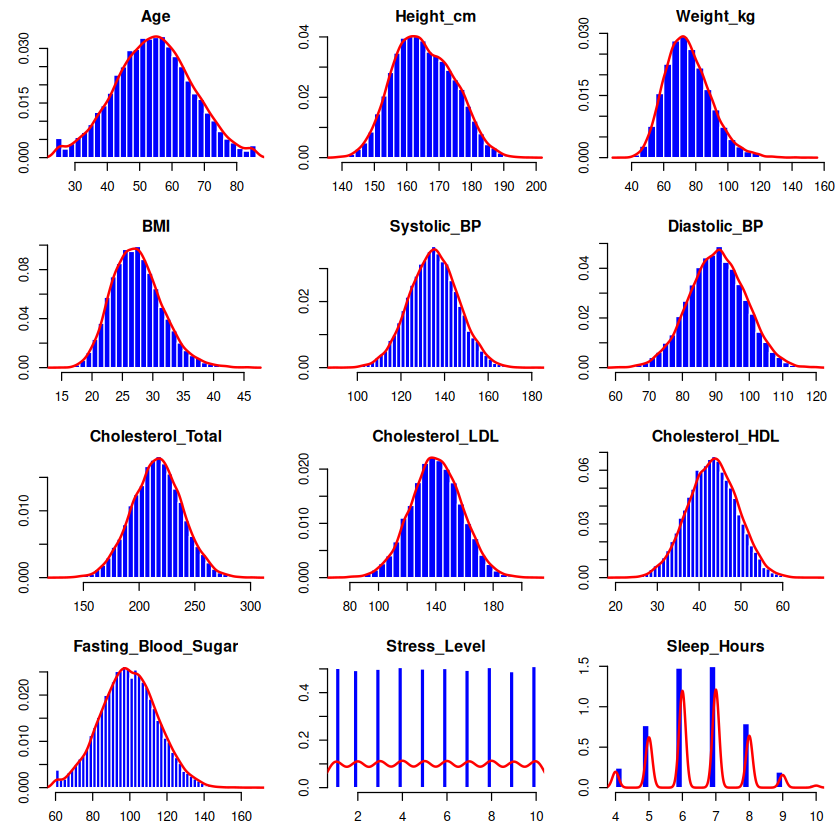

In [61]:
# Histogrammes des variables quantitatives
par(mfrow=c(4,3), mar=c(3,3,2,1))
for (v in quant_vars) {
  hist(df[[v]], main=v, xlab="", col="blue", border="white",
       breaks=40, probability=TRUE)
  lines(density(df[[v]]), col="red", lwd=2)
}

Nous remarquons que Stress_Level et Sleep_Hours ne suivent clairement pas une loi normale, ce qui est logique puisque nous avions hésité à les considérer comme des variables qualitatives : elles prennent des valeurs discrètes. De plus, Height_cm et Weight_kg dévient aussi assez clairement d'une loi normale, tandis que Cholesterol_LDL et BMI ne semblent également pas suivre cette loi.

In [18]:
# Test de normalité (Shapiro-Wilk, sous-échantillon n=500)
cat("=== Tests de Shapiro-Wilk (H0 : normalité) ===\n")
set.seed(42)
idx <- sample(nrow(df), 500)  #Pour ne pas avoir un test trop sensible
for (v in quant_vars) {
  sw <- shapiro.test(df[[v]][idx])
  cat(sprintf("  %-30s W=%.3f, p=%.4f  → %s\n",
              v, sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))
}

=== Tests de Shapiro-Wilk (H0 : normalité) ===
  Age                            W=0.995, p=0.1275  → Normale
  Height_cm                      W=0.991, p=0.0050  → Non normale
  Weight_kg                      W=0.969, p=0.0000  → Non normale
  BMI                            W=0.981, p=0.0000  → Non normale
  Systolic_BP                    W=0.996, p=0.2882  → Normale
  Diastolic_BP                   W=0.996, p=0.2433  → Normale
  Cholesterol_Total              W=0.997, p=0.5772  → Normale
  Cholesterol_LDL                W=0.994, p=0.0389  → Non normale
  Cholesterol_HDL                W=0.995, p=0.1528  → Normale
  Fasting_Blood_Sugar            W=0.996, p=0.2451  → Normale
  Stress_Level                   W=0.934, p=0.0000  → Non normale
  Sleep_Hours                    W=0.936, p=0.0000  → Non normale


Nous effectuons des tests de normalité de Shapiro-Wilk sur toutes nos variables quantitatives. Nos observations précédentes sont avérées : Height_cm, Weight_kg, BMI, Cholesterol_LDL, Stress_Level et Sleep_Hours ne suivent pas une loi normale. Ces deux dernières ne peuvent clairement pas être ramenées à des distributions normales. Cependant, nous pensons qu'il est possible d'approcher une distribution presque normale pour les autres grâce à une transformation.

Weight_kg W=0.968, p=0.0000  → Non normale


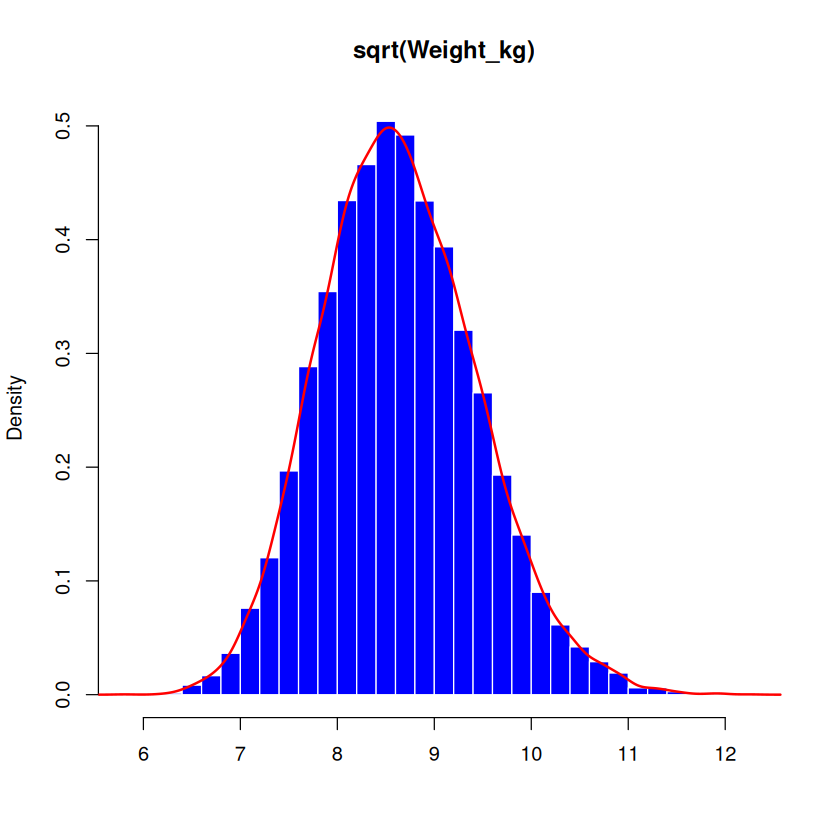

In [62]:
#Transformation de Weight_kg en sqrt(Weight_kg)
hist(sqrt(df[["Weight_kg"]]), 
     main="sqrt(Weight_kg)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Weight_kg"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Weight_kg"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Height_cm W=0.991, p=0.0051  → Non normale


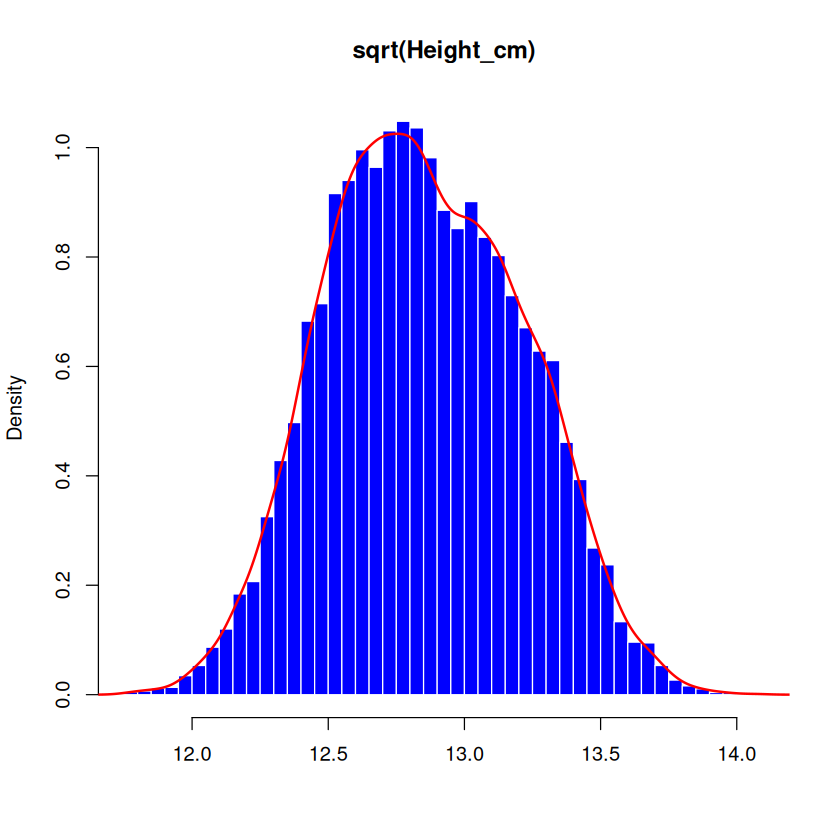

In [63]:
#Transformation de Height_cm en sqrt(Height_cm)
hist(sqrt(df[["Height_cm"]]), 
     main="sqrt(Height_cm)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Height_cm"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Height_cm"]][idx])
cat(sprintf("Height_cm W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Weight_kg W=0.987, p=0.0002  → Non normale


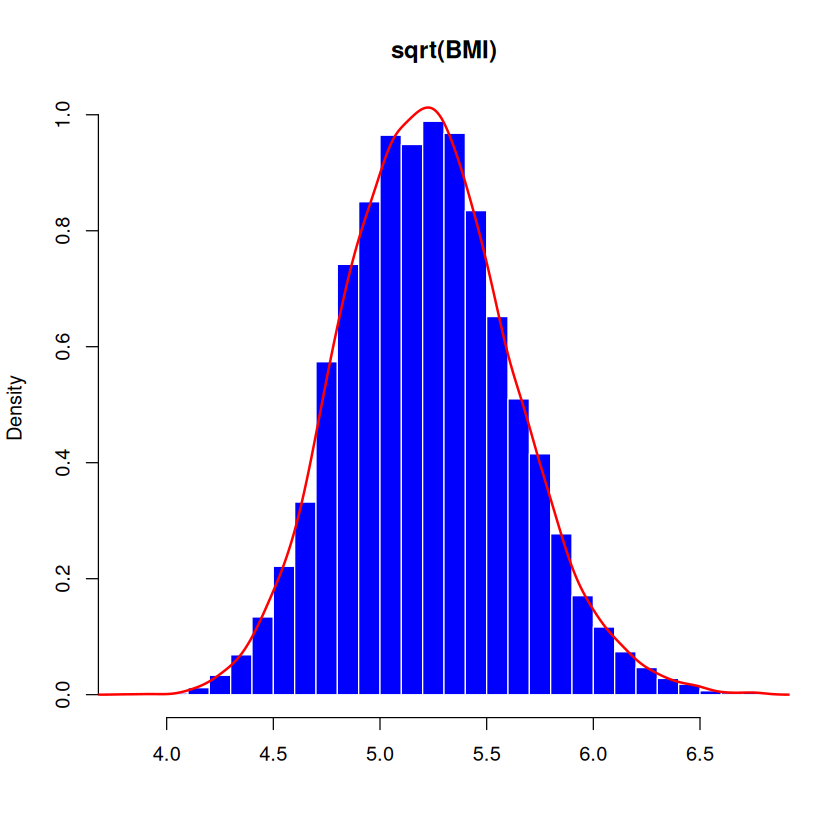

In [111]:
#Transformation de BMI en sqrt(BMI)
hist(sqrt(df[["BMI"]]), 
     main="sqrt(BMI)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["BMI"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["BMI"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Weight_kg W=0.998, p=0.9351  → Normale


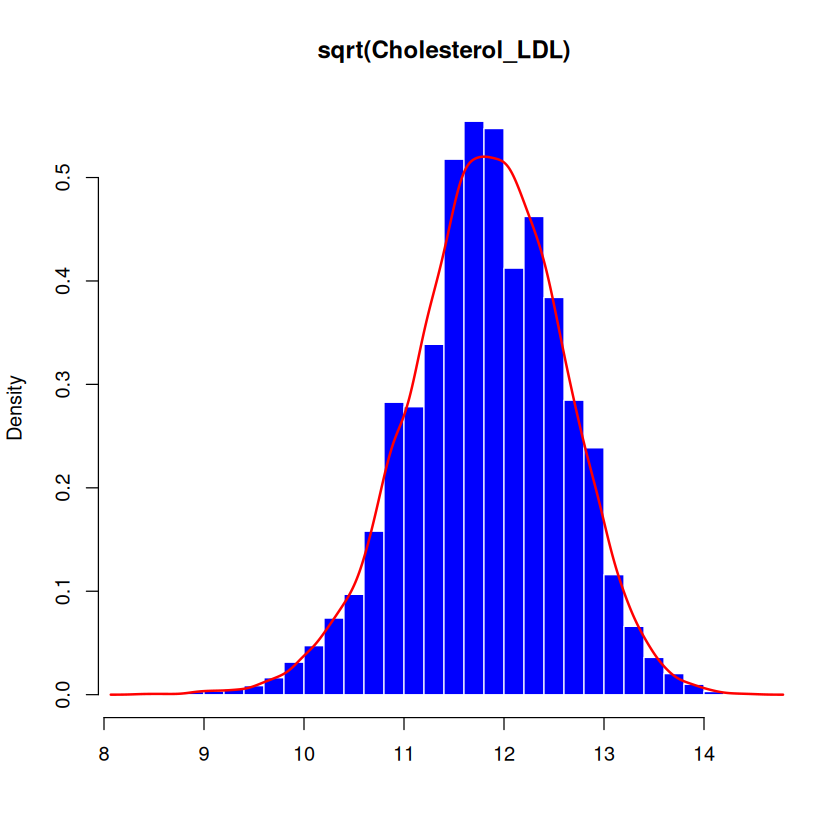

In [113]:
#Transformation de Cholesterol_LDL en sqrt(Cholesterol_LDL)
hist(sqrt(df[["Cholesterol_LDL"]]), 
     main="sqrt(Cholesterol_LDL)", 
     xlab="", 
     col="blue", 
     border="white",
     breaks=40, 
     probability=TRUE)

lines(density(sqrt(df[["Cholesterol_LDL"]])), col="red", lwd=2)

idx <- sample(nrow(df), 500)
sw <- shapiro.test(df[["Cholesterol_LDL"]][idx])
cat(sprintf("Weight_kg W=%.3f, p=%.4f  → %s\n",
              sw$statistic, sw$p.value,
              ifelse(sw$p.value > 0.05, "Normale", "Non normale")))

Nous remarquons que seule sqrt(Cholesterol_LDL) est normale. Notre idée de transformation n'a donc pas fonctionné en général. Ce n'est cependant pas très important car les distributions originales de toutes nos variables quantitatives sont symétriques. Nous décidons donc de conserver nos variables originelles, sans transformation, dans la suite de notre projet.

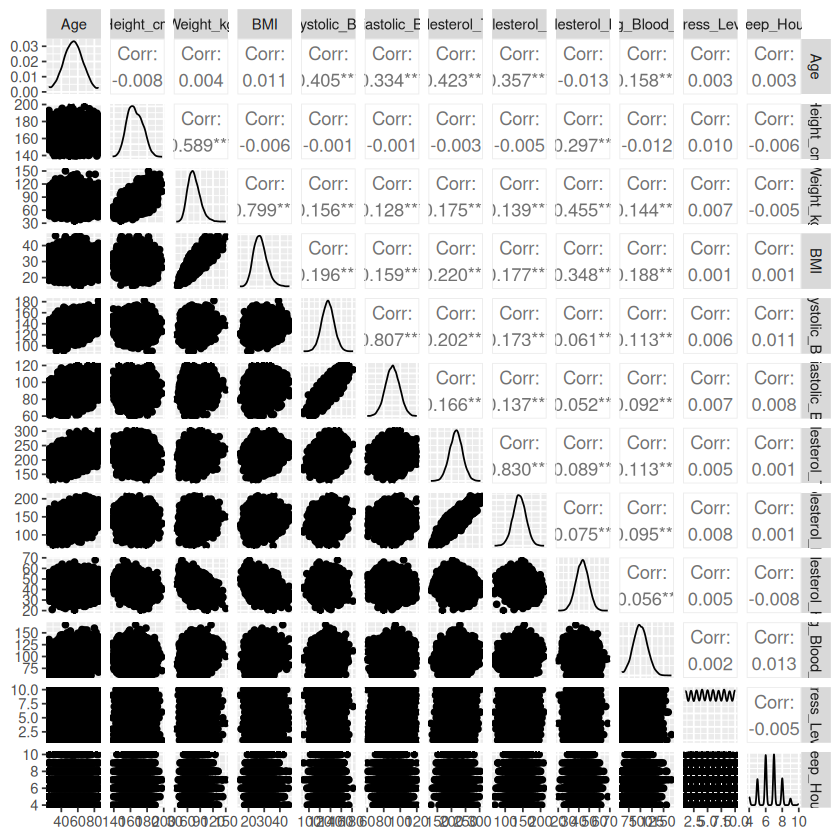

In [26]:
#Plot et corrélation des variables quantitatives 2 à 2
ggpairs(df[, c(1, 3:11, 16:17)])

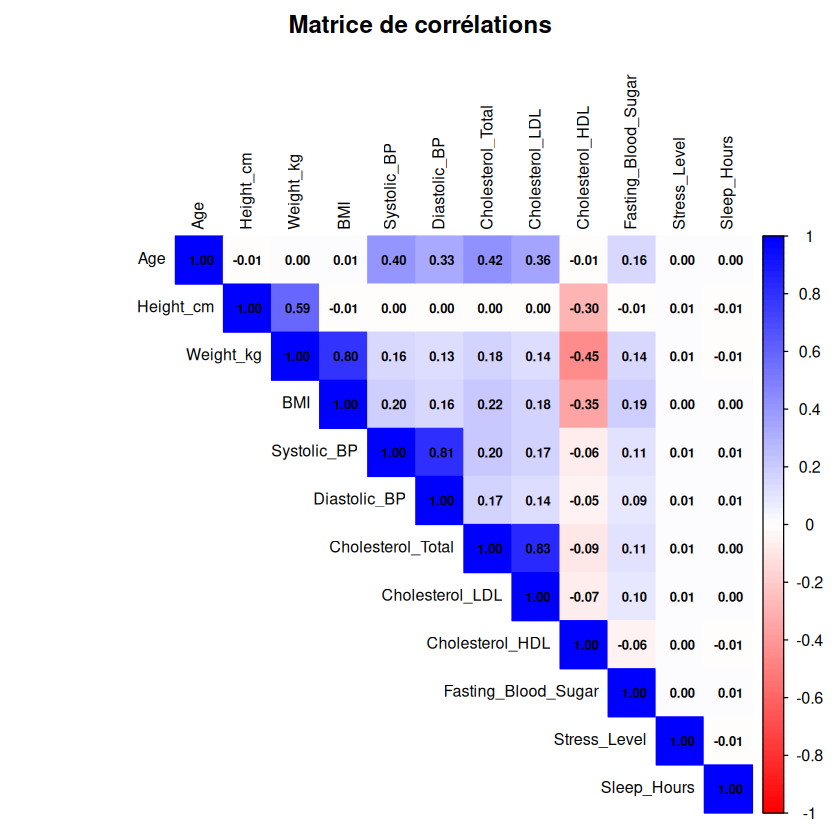

In [64]:
# Matrice de corrélations
corr_mat <- cor(df_quant)
corrplot(corr_mat, method="color", type="upper",
         addCoef.col="black", number.cex=0.65,
         tl.cex=0.8, tl.col="black",
         col=colorRampPalette(c("red","white","blue"))(100),
         title="Matrice de corrélations", mar=c(0,0,2,0))

#Dire quelles corrélations sortent du lot

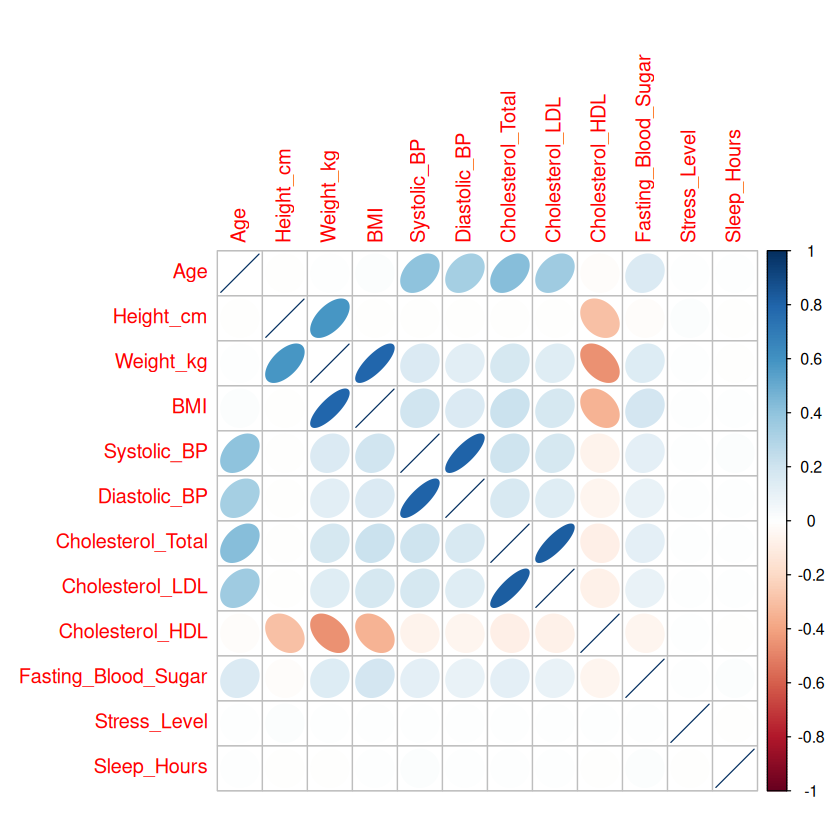

In [65]:
#Ellipses de corrélation
corrplot(cor(df[, c(1, 3:11, 16:17)]),method="ellipse")

Nous remarquons grâce à ces 3 matrices qu'il existe une forte corrélation positive entre BMI et Weight_kg, Diastolic_BP et Systolic_BP et entre Cholesterol_LDL et Cholesterol_HDL. Nous remarquons une corrélation positive entre Weight_kg et Height_cm. Age semble aussi corrélé positivement avec Systolic_BP, Diastolic_BP, Cholesterol_LDL et Cholesterol_Total. Nous obserons aussi 3 corrélations négatives : entre Cholesterol_HDL et Weight_kg, entre Cholesterol_HDL et Height_cm ainsi qu'entre Cholesterol_HDL et BMI.

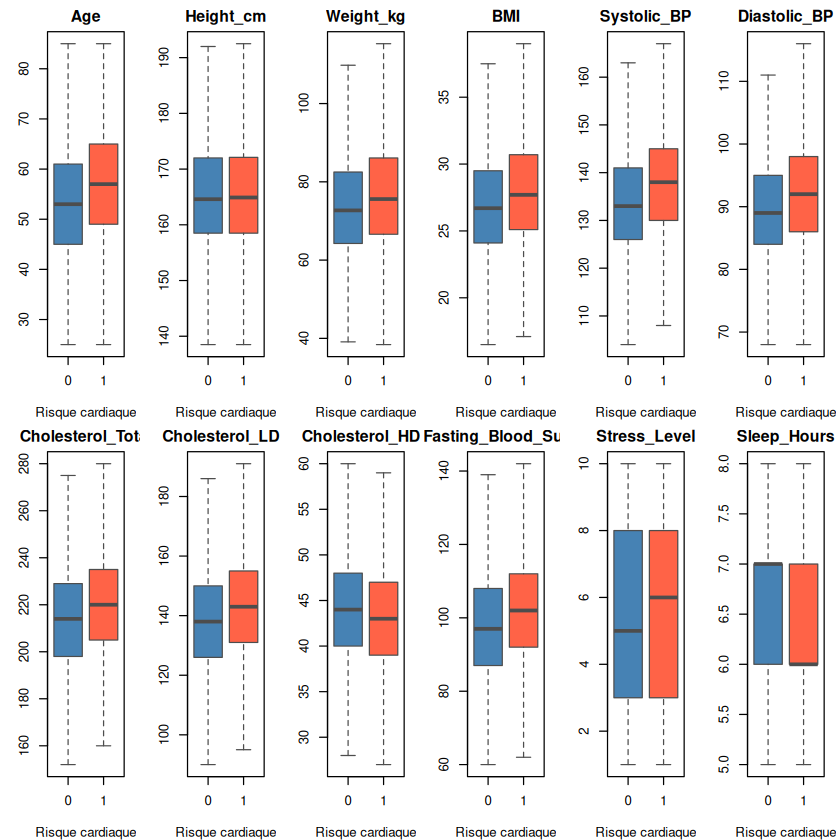

In [97]:
# Boxplots des variables quantitatives selon Heart_Disease_Risk
par(mfrow=c(2,6), mar=c(4,3,2,1))
for (v in quant_vars) {
  boxplot(df[[v]] ~ df$Heart_Disease_Risk,
          main=v, xlab="Risque cardiaque", ylab=v,
          col=c("steelblue","tomato"), border="gray30", outline=FALSE)
}

Nous remarquons que la variable Height_cm est la seule à sembler indépendante du risque de maladie cardiaque : aucune différence notable en termes de moyenne et de distribution. Au contraire, pour les autres variables, nous observons des différences plus ou moins légères selon le risque de maladie cardiaque. Finalement, nous remarquons PARLER DE SLEEP.

## Analyse des variables qualitatives ##

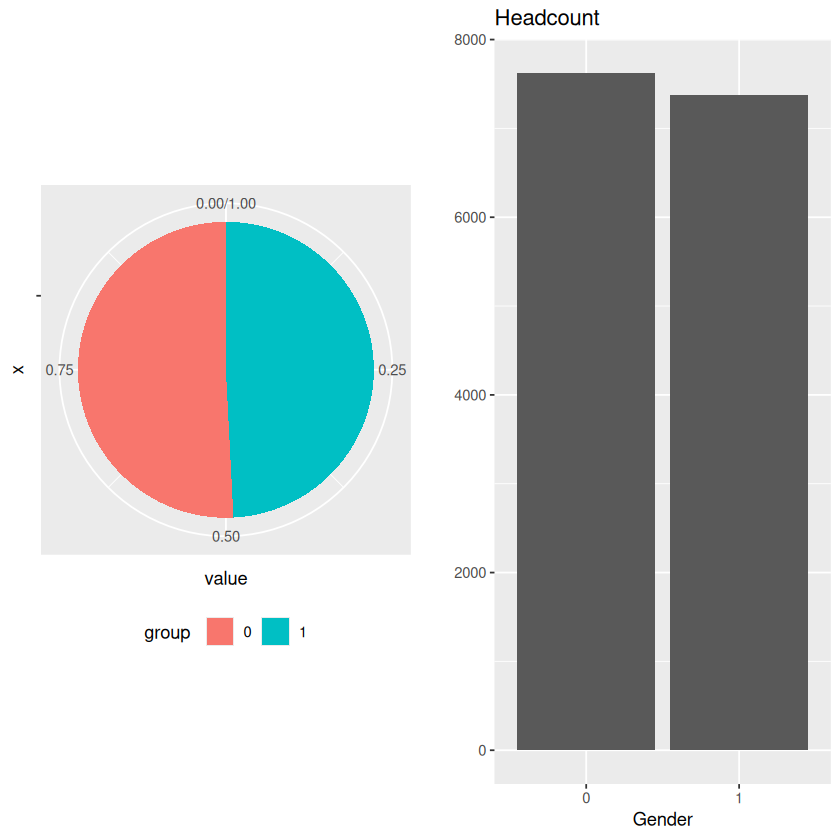

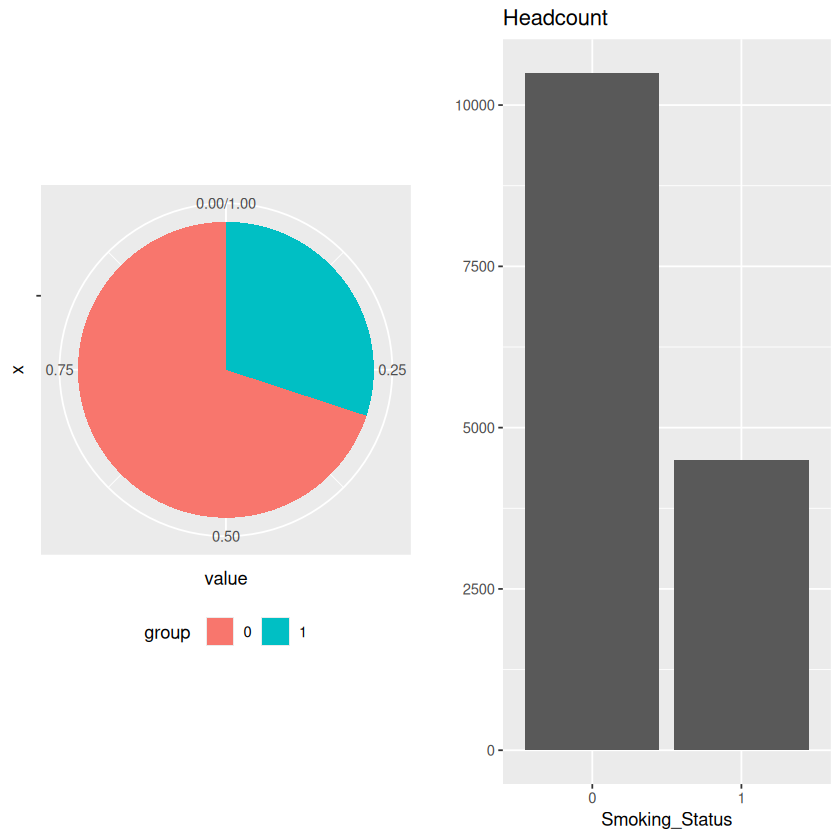

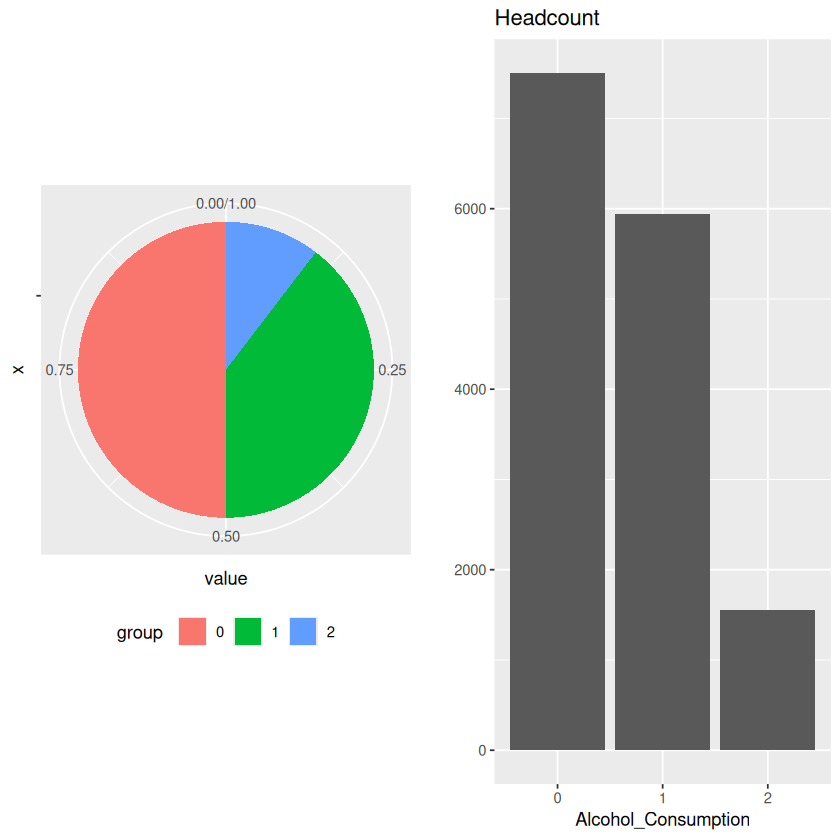

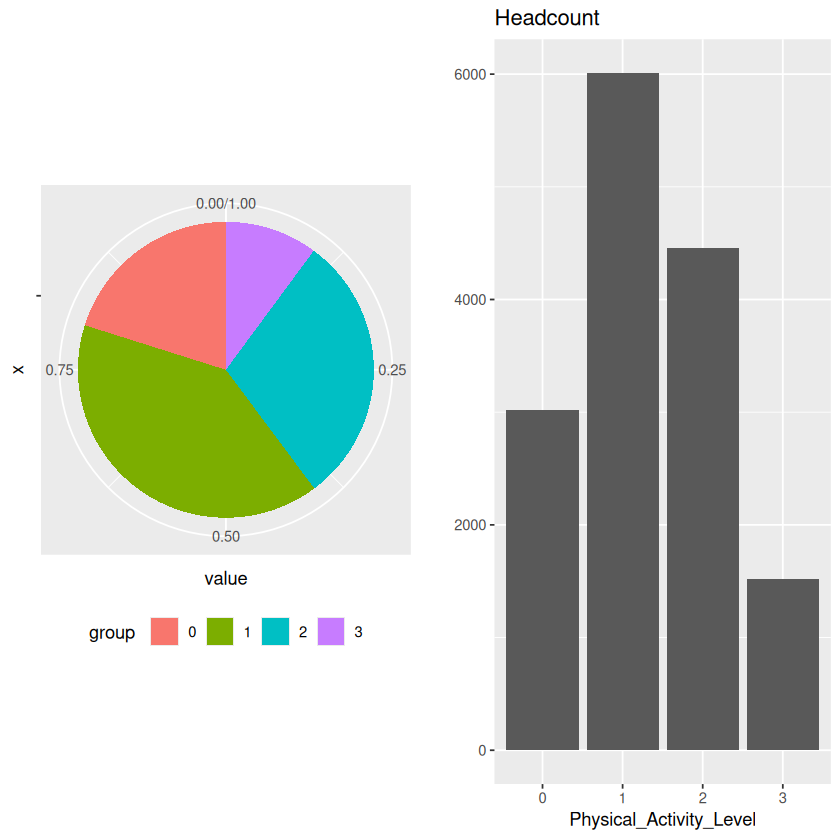

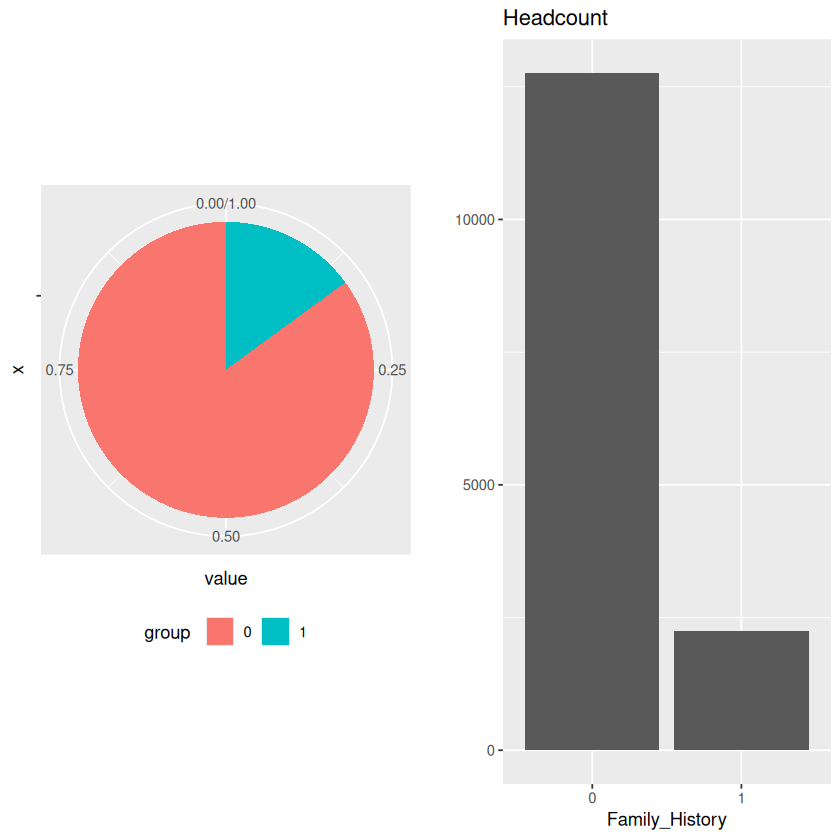

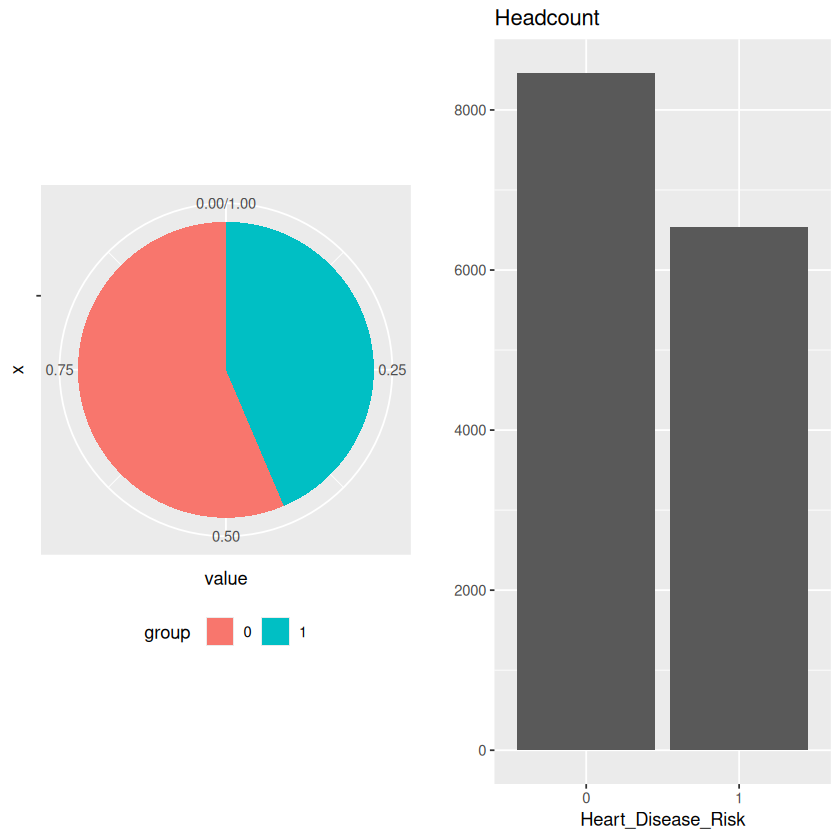

In [66]:
#Analyse des variables qualitatives

g1<-ggplot(df, aes(x=Gender))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
a<- data.frame(group = levels(df$Gender),
                 value = as.vector(table(df$Gender))/nrow(df))
g3<-ggplot(a, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g3,g1,ncol=2)


g4<-ggplot(df, aes(x=Smoking_Status))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
b<- data.frame(group = levels(df$Smoking_Status),
                 value = as.vector(table(df$Smoking_Status))/nrow(df))
g5<-ggplot(b, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g5,g4,ncol=2)


g6<-ggplot(df, aes(x=Alcohol_Consumption))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
c<- data.frame(group = levels(df$Alcohol_Consumption),
                 value = as.vector(table(df$Alcohol_Consumption))/nrow(df))
g7<-ggplot(c, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g7,g6,ncol=2)

g8<-ggplot(df, aes(x=Physical_Activity_Level))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
d<- data.frame(group = levels(df$Physical_Activity_Level),
                 value = as.vector(table(df$Physical_Activity_Level))/nrow(df))
g9<-ggplot(d, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g9,g8,ncol=2)

g10<-ggplot(df, aes(x=Family_History))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
e<- data.frame(group = levels(df$Family_History),
                 value = as.vector(table(df$Family_History))/nrow(df))
g11<-ggplot(e, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g11,g10,ncol=2)

g12<-ggplot(df, aes(x=Heart_Disease_Risk))+
           geom_bar()+
           ylab("")+
           ggtitle("Headcount")
f<- data.frame(group = levels(df$Heart_Disease_Risk),
                 value = as.vector(table(df$Heart_Disease_Risk))/nrow(df))
g13<-ggplot(f, aes(x="",y=value, fill=group))+
           geom_bar(width=1,stat="identity")+
           coord_polar("y",start=0)+
           theme(legend.position="bottom")
grid.arrange(g13,g12,ncol=2)

############# GENDER #############

   
       0    1
  0 4303 3319
  1 4157 3221

,0,1,Sum
0,4303,3319,7622
1,4157,3221,7378
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 0.014786, df = 1, p-value = 0.9032


   
            0         1
  0 0.5645500 0.4354500
  1 0.5634318 0.4365682
   
            0         1
  0 0.5086288 0.5074924
  1 0.4913712 0.4925076


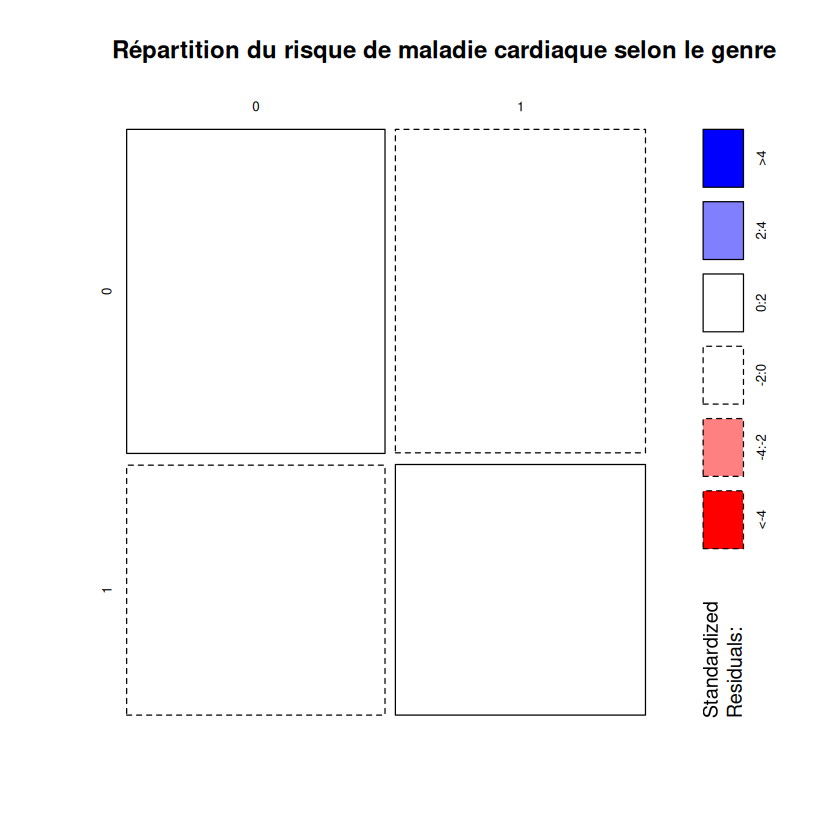


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 0.014786, df = 1, p-value = 0.9032


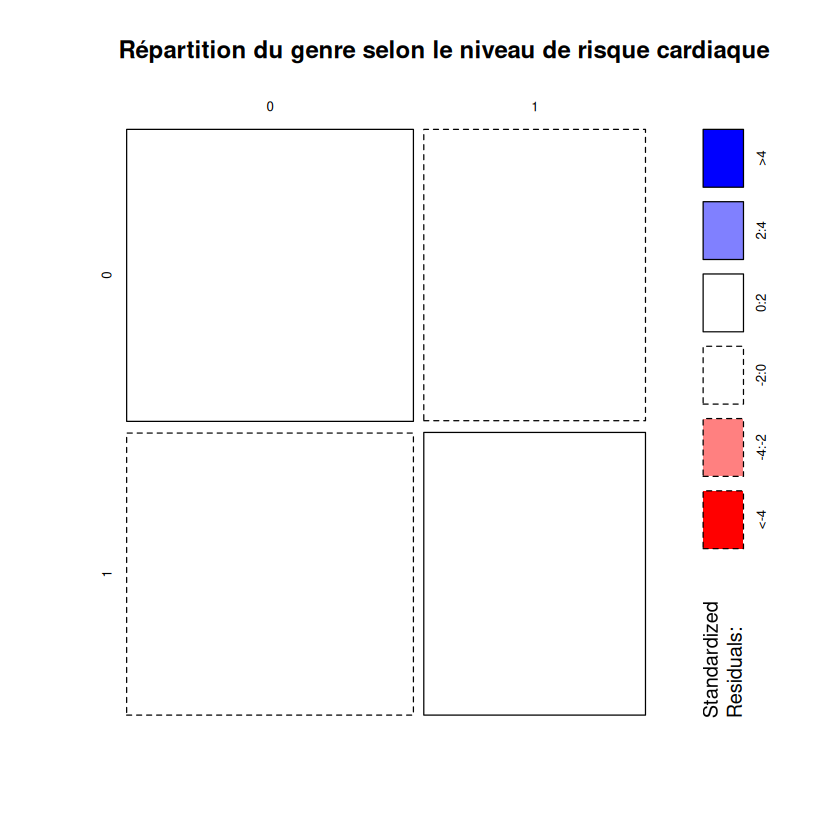

In [67]:
#Analyse des variables qualitatives (par rapport a Heart_Disease_Risk

###### GENDER ######
par(mfrow=c(1,1))
cat("############# GENDER #############")
contingency_table <- table(df$Gender, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Gender, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon le genre")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition du genre selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#Gender n'a aucun effet sur le risque


############# SMOKING_STATUS #############

   
       0    1
  0 7121 3374
  1 1339 3166

,0,1,Sum
0,7121,3374,10495
1,1339,3166,4505
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 1861.9, df = 1, p-value < 2.2e-16


   
            0         1
  0 0.6785136 0.3214864
  1 0.2972253 0.7027747
   
            0         1
  0 0.8417258 0.5159021
  1 0.1582742 0.4840979


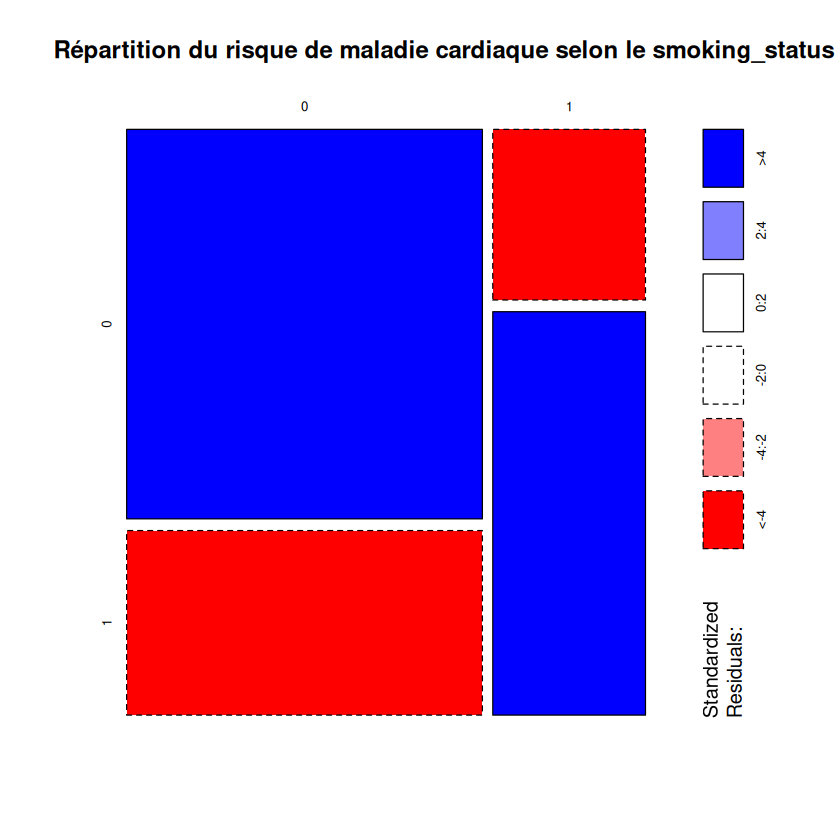


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 1861.9, df = 1, p-value < 2.2e-16


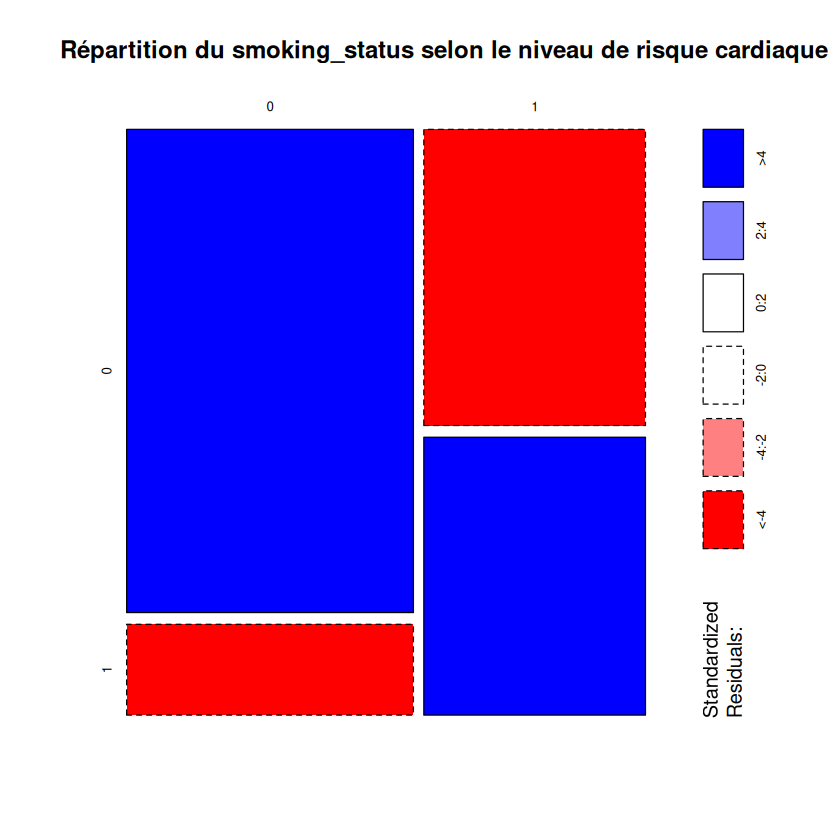

In [68]:
###### SMOKING_STATUS ######
par(mfrow=c(1,1))
cat("\n############# SMOKING_STATUS #############")
contingency_table <- table(df$Smoking_Status, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Smoking_Status, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon le smoking_status")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition du smoking_status selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#Si la personne fume, elle a plus de risque que si elle ne fumait pas.


############# ALCOHOL_CONSUMPTION #############

   
       0    1
  0 4202 3300
  1 3384 2555
  2  874  685

,0,1,Sum
0,4202,3300,7502
1,3384,2555,5939
2,874,685,1559
Sum,8460,6540,15000



	Pearson's Chi-squared test

data:  contingency_table
X-squared = 1.343, df = 2, p-value = 0.5109


   
            0         1
  0 0.5601173 0.4398827
  1 0.5697929 0.4302071
  2 0.5606158 0.4393842
   
            0         1
  0 0.4966903 0.5045872
  1 0.4000000 0.3906728
  2 0.1033097 0.1047401


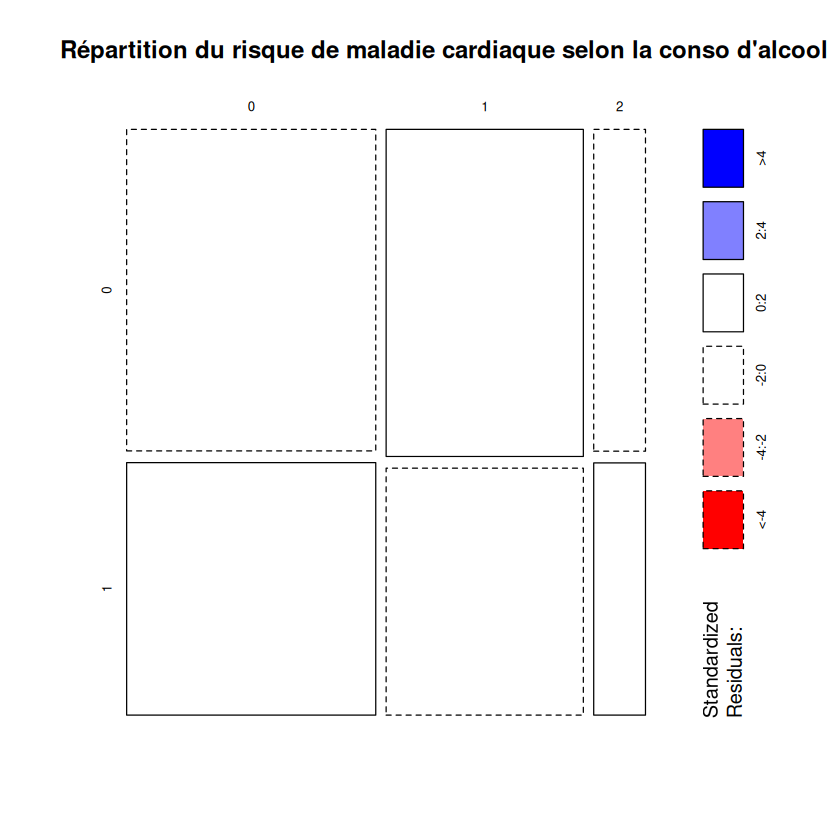


	Pearson's Chi-squared test

data:  contingency_table
X-squared = 1.343, df = 2, p-value = 0.5109


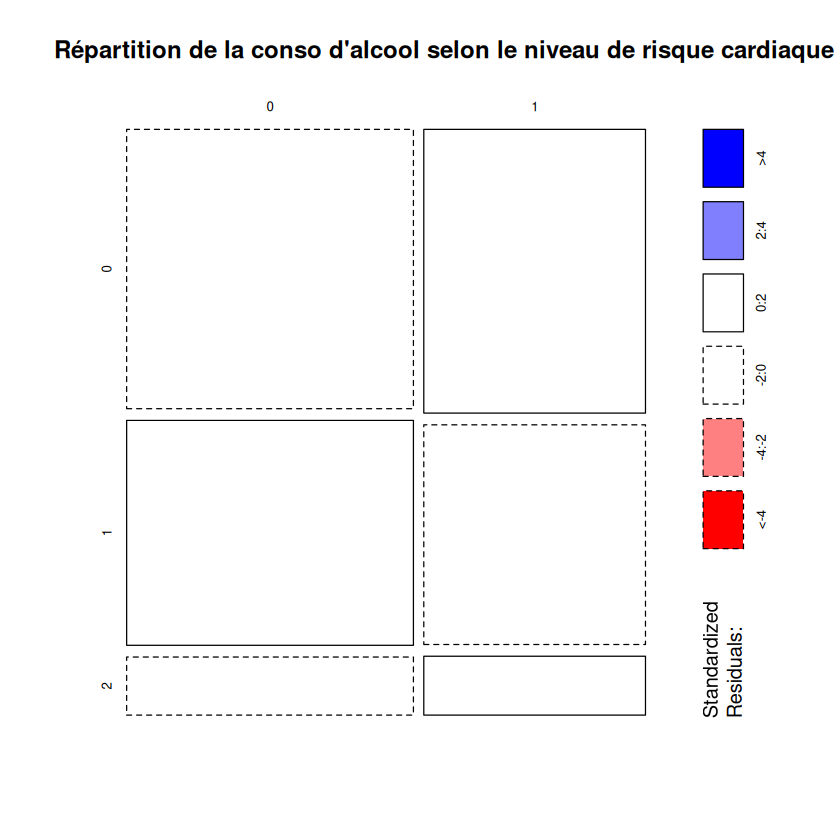

In [69]:
###### ALCOHOL_CONSUMPTION ######
par(mfrow=c(1,1))
cat("\n############# ALCOHOL_CONSUMPTION #############")
contingency_table <- table(df$Alcohol_Consumption, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Alcohol_Consumption, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon la conso d'alcool")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de la conso d'alcool selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#La conso d'alcool n'a pas d'effet sur le risque


############# PHYSICAL_ACTIVITY_LEVEL #############

   
       0    1
  0 1334 1686
  1 3244 2765
  2 2819 1634
  3 1063  455

,0,1,Sum
0,1334,1686,3020
1,3244,2765,6009
2,2819,1634,4453
3,1063,455,1518
Sum,8460,6540,15000



	Pearson's Chi-squared test

data:  contingency_table
X-squared = 398.85, df = 3, p-value < 2.2e-16


   
            0         1
  0 0.4417219 0.5582781
  1 0.5398569 0.4601431
  2 0.6330564 0.3669436
  3 0.7002635 0.2997365
   
             0          1
  0 0.15768322 0.25779817
  1 0.38345154 0.42278287
  2 0.33321513 0.24984709
  3 0.12565012 0.06957187


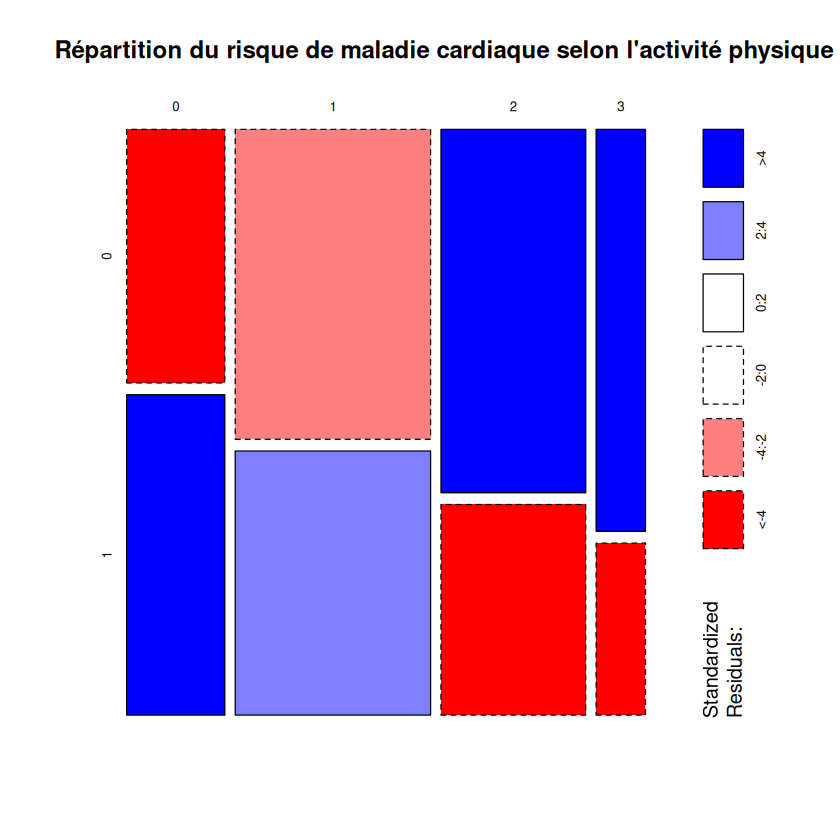


	Pearson's Chi-squared test

data:  contingency_table
X-squared = 398.85, df = 3, p-value < 2.2e-16


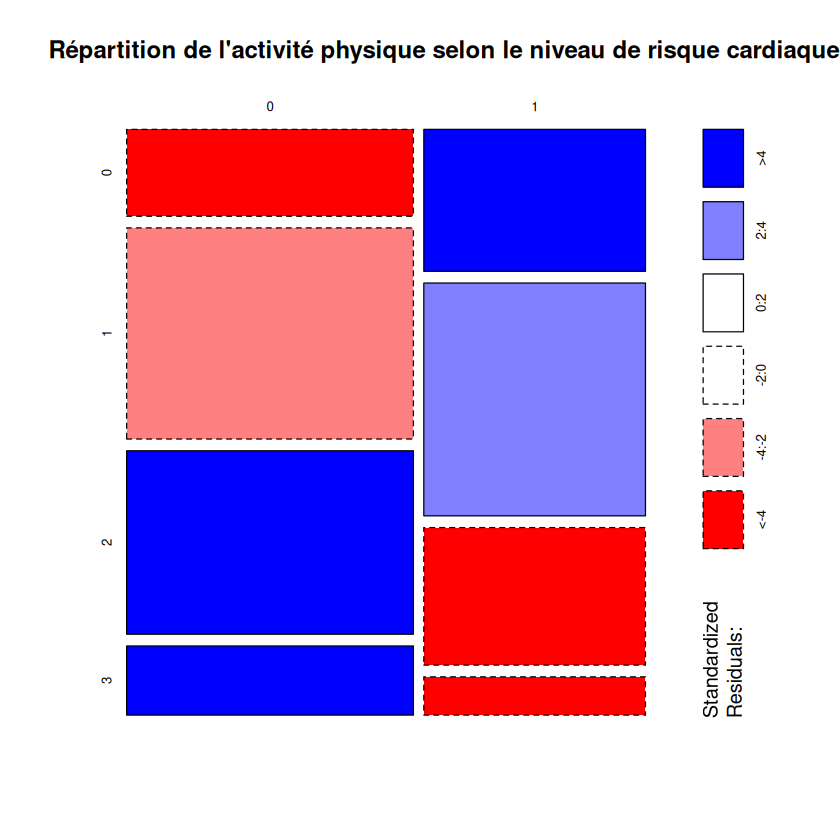

In [49]:
###### PHYSICAL_ACTIVITY_LEVEL ######
par(mfrow=c(1,1))
cat("\n############# PHYSICAL_ACTIVITY_LEVEL #############")
contingency_table <- table(df$Physical_Activity_Level, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Physical_Activity_Level, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon l'activité physique")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de l'activité physique selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#Moins on fait de sport, plus on a de risques.


############# FAMILY_HISTORY #############

   
       0    1
  0 7729 5028
  1  731 1512

,0,1,Sum
0,7729,5028,12757
1,731,1512,2243
Sum,8460,6540,15000



	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 606.88, df = 1, p-value < 2.2e-16


   
            0         1
  0 0.6058634 0.3941366
  1 0.3259028 0.6740972
   
             0          1
  0 0.91359338 0.76880734
  1 0.08640662 0.23119266


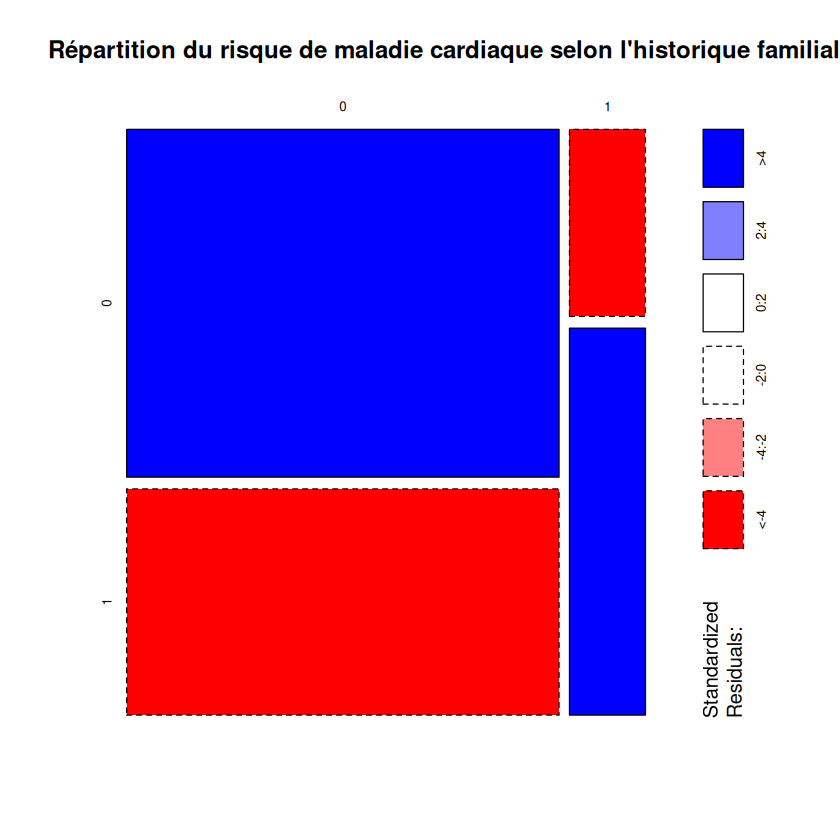


	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_table
X-squared = 606.88, df = 1, p-value < 2.2e-16


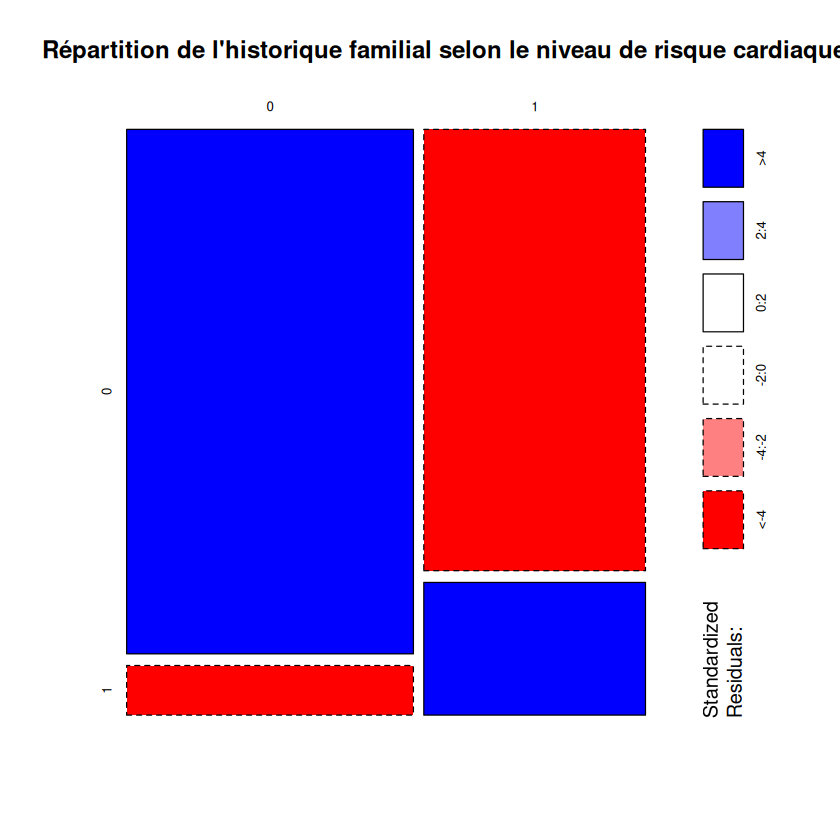

In [85]:
###### FAMILY_HISTORY ######
par(mfrow=c(1,1))
cat("\n############# FAMILY_HISTORY #############")
contingency_table <- table(df$Family_History, df$Heart_Disease_Risk)
contingency_table
contingency_table_margins <- addmargins(contingency_table)
contingency_table_margins
chisq.test(contingency_table)

# Table de contingence
contingency_table <- table(df$Family_History, df$Heart_Disease_Risk)

# Calcul des profils-lignes (somme de chaque ligne = 1)
profile_rows <- prop.table(contingency_table, margin = 1)
print(profile_rows)

mosaicplot(contingency_table, shade = TRUE, main = "Répartition du risque de maladie cardiaque selon l'historique familial")

# Calcul des profils-colonnes (somme de chaque colonne = 1)
profile_cols <- prop.table(contingency_table, margin = 2)
print(profile_cols)

mosaicplot(t(contingency_table), shade = TRUE, main = "Répartition de l'historique familial selon le niveau de risque cardiaque")

chisq.test(contingency_table)

#Si y a pas d'historique, on a moins de risque

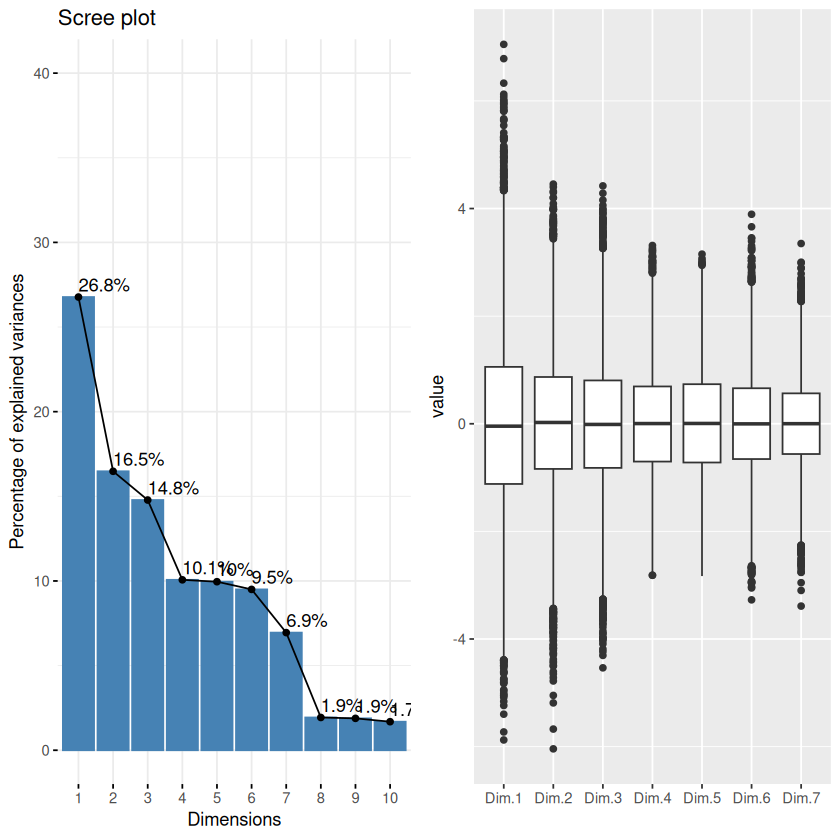

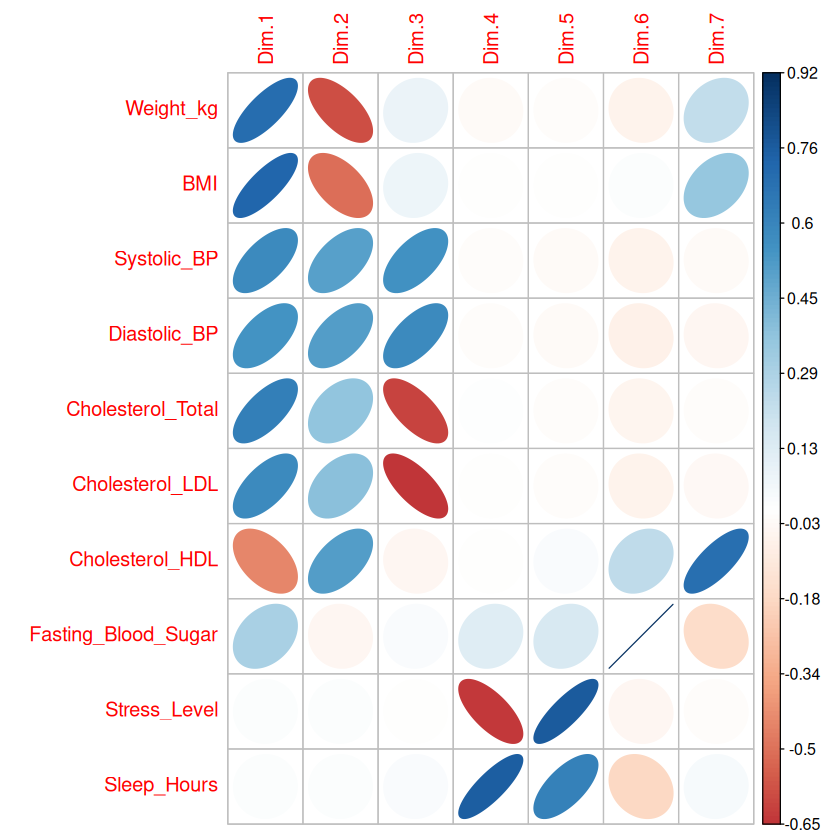

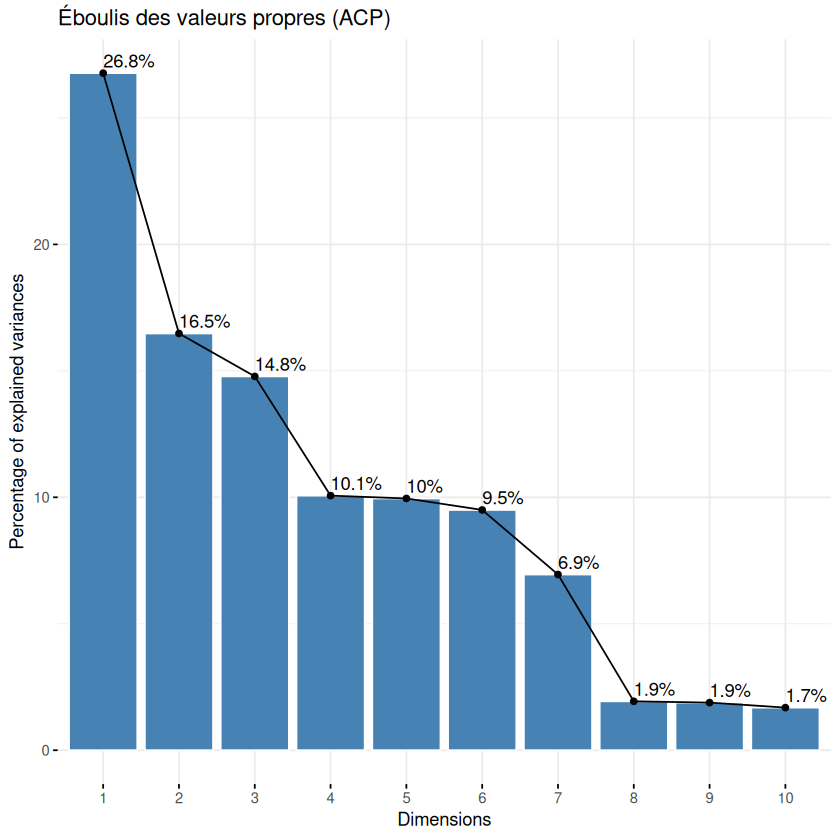

In [101]:
### ACP ####

# ACP réduite
acp <- PCA(df[,c(1, 3:11, 16:17)], scale.unit = TRUE,
           graph = FALSE, quali.sup = 1, quanti.sup = 2, ncp = 7)
# Décroissance des valeurs propres
g1<-fviz_eig(acp, addlabels = TRUE, ylim = c(0, 40))
g2<-ggplot(melt(acp$ind$coord),aes(x=Var2,y=value))+
  geom_boxplot()+
  xlab("")
grid.arrange(g1,g2,ncol=2)
# 
corrplot(acp$var$cor, is.corr=FALSE,method="ellipse")

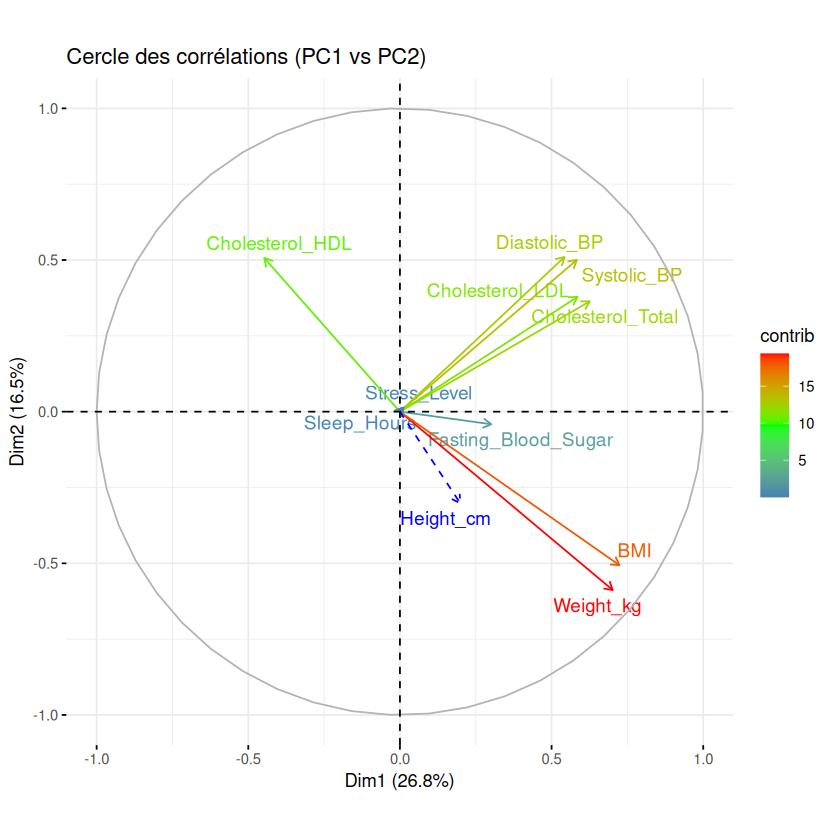

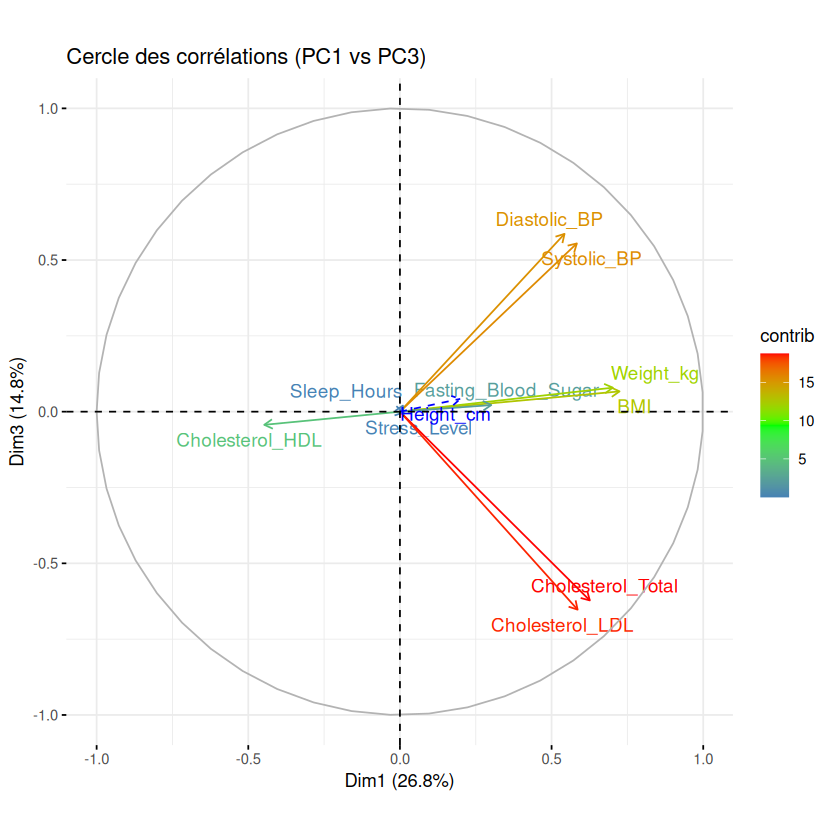

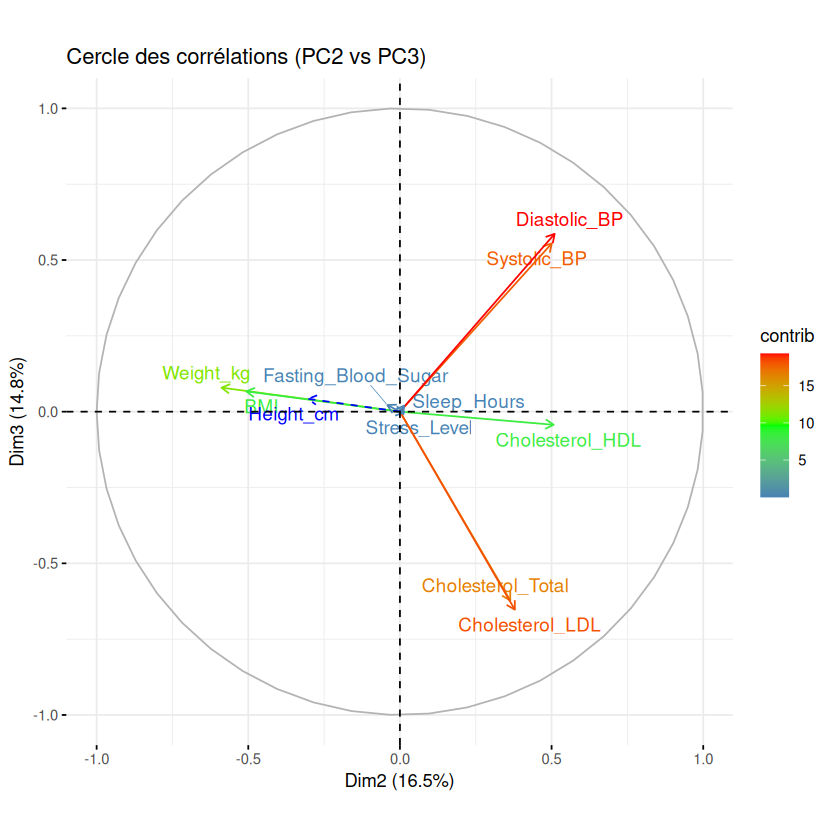

In [108]:
# Cercles des corrélations
fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC1 vs PC2)")

fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC1 vs PC3)",axes=c(1,3))

fviz_pca_var(acp,
             col.var="contrib",
             gradient.cols=c("steelblue","green","red"),
             repel=TRUE,
             title="Cercle des corrélations (PC2 vs PC3)",axes=c(2,3))